# 1. Introduction

This project focuses on analyzing a movie dataset.

# 2. Data Loading and Preprocessing

### 2.1. Load the dataset and libraries

In [456]:
import pandas as pd

In [457]:
df = pd.read_csv('Letterbox Movie Classification Dataset.csv')

df.head()

,Unnamed: 0,Film_title,Director,Average_rating,Genres,Runtime,Original_language,Description,Studios,Watches,List_appearances,Likes,Fans,Lowest★,Medium★★★,Highest★★★★★,Total_ratings
0,0,The Fan,Eckhart Schmidt,3.57,"['Horror', 'Drama']",92.0,German,The hero-worship that Simone has for a pop sin...,['Barbara Moorse Workshop'],12841,11032,3763,79,129,1660,714,9042
1,1,Mad Max: Fury Road,George Miller,4.18,"['Adventure', 'Science Fiction', 'Action']",121.0,English,An apocalyptic story set in the furthest reach...,"['Warner Bros. Pictures', 'Village Roadshow Pi...",2488721,331681,927538,38000,12530,158356,511140,1682389
2,2,Suspiria,Dario Argento,3.93,['Horror'],99.0,English,An American newcomer to a prestigious German b...,['Seda Spettacoli'],618171,220094,219548,13000,2814,53427,88628,443757
3,3,Lost in Translation,Sofia Coppola,3.79,"['Drama', 'Comedy', 'Romance']",102.0,English,"Two lost souls visiting Tokyo -- the young, ne...","['American Zoetrope', 'Elemental Films']",1596190,254180,493248,38000,15167,155110,193717,1076949
4,4,Akira,Katsuhiro Otomo,4.28,"['Animation', 'Action', 'Science Fiction']",124.0,Japanese,A secret military project endangers Neo-Tokyo ...,"['MBS', 'Sumitomo Corporation', 'TOHO', 'Studi...",873068,175586,341567,21000,1822,40850,196532,600721


In [458]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         10000 non-null  int64  
 1   Film_title         10000 non-null  str    
 2   Director           10000 non-null  str    
 3   Average_rating     10000 non-null  float64
 4   Genres             10000 non-null  str    
 5   Runtime            10000 non-null  float64
 6   Original_language  10000 non-null  str    
 7   Description        10000 non-null  str    
 8   Studios            10000 non-null  str    
 9   Watches            10000 non-null  int64  
 10  List_appearances   10000 non-null  int64  
 11  Likes              10000 non-null  int64  
 12  Fans               10000 non-null  int64  
 13  Lowest★            10000 non-null  int64  
 14  Medium★★★          10000 non-null  int64  
 15  Highest★★★★★       10000 non-null  int64  
 16  Total_ratings      10000 non-null 

### 2.2. Preprocessing

Deleting unnecessary columns.

In [459]:
df.drop(columns=['Unnamed: 0', 'Film_title', 'Director', 'Description', 'Studios', 'Likes', 'Fans', 'Lowest★', 'Medium★★★', 'Highest★★★★★'], inplace=True)

Cleaning the 'Genres' column by converting string representations into Python lists

In [460]:
unique_genres = dict()
df['Genres'] = df['Genres'].astype(object)

for i, s in enumerate(df['Genres']):
    s = s.strip("[]").replace("'", "")
    l = []
    for g in s.split(','):
        l.append(g.strip())
        
        unique_genres[g.strip()] = unique_genres.get(g.strip(), 0) + 1
    df.at[i, 'Genres'] = l
    

In [461]:
unique_genres = pd.DataFrame(unique_genres.items(), columns=['Genre', 'Count'])
unique_genres.sort_values(by='Count', ascending=False, inplace=True)

Filtering for top genres

In [462]:
top_genres = unique_genres[unique_genres['Count']>200]['Genre'].tolist()
top_genres

['Drama',
 'Comedy',
 'Thriller',
 'Action',
 'Horror',
 'Crime',
 'Adventure',
 'Romance',
 'Science Fiction',
 'Fantasy',
 'Mystery',
 'Family',
 'Animation',
 'History',
 'Documentary',
 'War',
 'Music',
 'Western',
 'TV Movie']

In [463]:
columns_to_drop = unique_genres[~unique_genres['Genre'].isin(top_genres)]['Genre'].tolist()
columns_to_drop

['Unknown',
 'Show All…',
 'Epic heroes',
 'Superheroes in action-packed battles with villains',
 'Epic adventure and breathtaking battles',
 'Epic history and literature',
 'Fantasy adventure',
 'heroism',
 'and swordplay',
 'Captivating vision and Shakespearean drama',
 'Historical battles and epic heroism']

In [464]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

genre_encoded = mlb.fit_transform(df['Genres'])

genre_df = pd.DataFrame(genre_encoded, columns=mlb.classes_)

genre_df.drop(columns=columns_to_drop, inplace=True)

df = pd.concat([df, genre_df], axis=1)

df = df.drop('Genres', axis=1)

In [465]:
df.head()

,Average_rating,Runtime,Original_language,Watches,List_appearances,Total_ratings,Action,Adventure,Animation,Comedy,...,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
0,3.57,92.0,German,12841,11032,9042,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,4.18,121.0,English,2488721,331681,1682389,1,1,0,0,...,0,0,0,0,0,1,0,0,0,0
2,3.93,99.0,English,618171,220094,443757,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,3.79,102.0,English,1596190,254180,1076949,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,4.28,124.0,Japanese,873068,175586,600721,1,0,1,0,...,0,0,0,0,0,1,0,0,0,0


# 3. Data exploration and visualizations

In [466]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="white")

### 3.1. General information about the dataset

In [467]:
df.shape 

(10000, 25)

In [468]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Average_rating     10000 non-null  float64
 1   Runtime            10000 non-null  float64
 2   Original_language  10000 non-null  str    
 3   Watches            10000 non-null  int64  
 4   List_appearances   10000 non-null  int64  
 5   Total_ratings      10000 non-null  int64  
 6   Action             10000 non-null  int64  
 7   Adventure          10000 non-null  int64  
 8   Animation          10000 non-null  int64  
 9   Comedy             10000 non-null  int64  
 10  Crime              10000 non-null  int64  
 11  Documentary        10000 non-null  int64  
 12  Drama              10000 non-null  int64  
 13  Family             10000 non-null  int64  
 14  Fantasy            10000 non-null  int64  
 15  History            10000 non-null  int64  
 16  Horror             10000 non-null 

### 3.2. Average Rating 

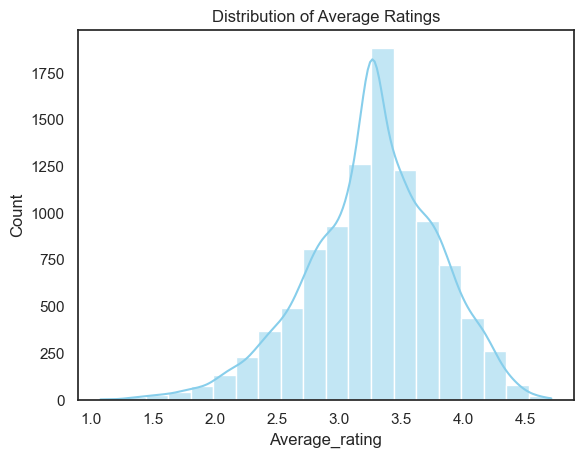

In [469]:

sns.histplot(df['Average_rating'], bins=20,kde=True, color='skyblue')
plt.title('Distribution of Average Ratings')

plt.show()

In [470]:
df['Average_rating'].describe()

count    10000.000000
mean         3.268535
std          0.525744
min          1.080000
25%          2.950000
50%          3.268535
75%          3.620000
max          4.710000
Name: Average_rating, dtype: float64

### 3.3. Runtime

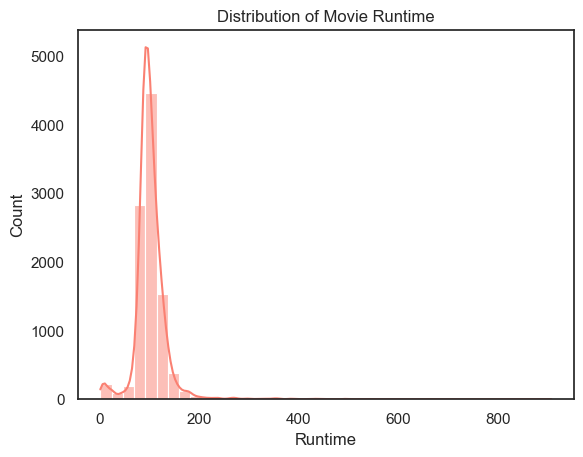

In [471]:
sns.histplot(df['Runtime'], bins=40,kde=True, color='salmon')
plt.title('Distribution of Movie Runtime')
plt.show()

In [472]:
df['Runtime'].describe()

count    10000.000000
mean       103.169352
std         38.070735
min          2.000000
25%         89.000000
50%         99.000000
75%        113.000000
max        907.000000
Name: Runtime, dtype: float64

### 3.4. Original Language

In [473]:
df['Original_language'].unique()

<StringArray>
[                          'German',                          'English',
                         'Japanese',                           'French',
                          'Spanish',                          'Italian',
                        'Cantonese',                       'Indonesian',
                           'Korean',               'No spoken language',
                          'Russian',                          'Swedish',
                           'Danish',                            'Dutch',
                           'Polish',                        'Hungarian',
                            'Mayan',                             'Thai',
                   'Greek (modern)',                  'Persian (Farsi)',
                        'Norwegian',                       'Portuguese',
                            'Czech',                          'Chinese',
                          'Turkish',                           'Telugu',
                           'Arabic', 

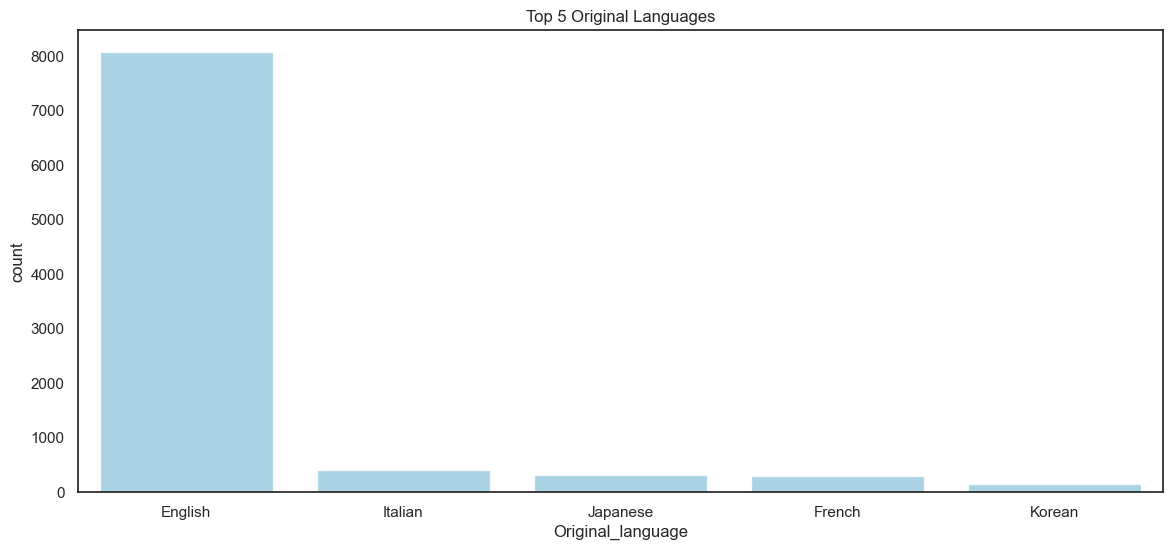

In [474]:
top_5_languages = df['Original_language'].value_counts().nlargest(5).index
plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='Original_language', order=top_5_languages, color='skyblue', alpha=0.8)
plt.title('Top 5 Original Languages')
plt.show()

In [475]:
counts = df['Original_language'].value_counts()
print(counts)

Original_language
English                             8074
Italian                              396
Japanese                             308
French                               291
Korean                               145
Spanish                              115
German                                96
No spoken language                    94
Chinese                               66
Danish                                60
Cantonese                             58
Russian                               43
Swedish                               32
Dutch                                 20
Polish                                20
Portuguese                            19
Romanian                              18
Persian (Farsi)                       15
Norwegian                             14
Arabic                                14
Czech                                 12
Hungarian                              9
Greek (modern)                         9
Hindi                                  

### 3.5. Watches, List_appearances, Total_ratings

In [476]:
df['Watches'].describe()

count    1.000000e+04
mean     1.703148e+05
std      4.585329e+05
min      2.000000e+00
25%      2.979750e+03
50%      1.842500e+04
75%      1.083580e+05
max      5.195503e+06
Name: Watches, dtype: float64

In [477]:
df['List_appearances'].describe()

count     10000.000000
mean      26868.798600
std       56751.328696
min          33.000000
25%        1674.000000
50%        6503.000000
75%       23908.250000
max      803670.000000
Name: List_appearances, dtype: float64

In [478]:
df['Total_ratings'].describe()

count    1.000000e+04
mean     1.063923e+05
std      2.947343e+05
min      0.000000e+00
25%      1.895000e+03
50%      1.182300e+04
75%      6.749875e+04
max      4.091037e+06
Name: Total_ratings, dtype: float64

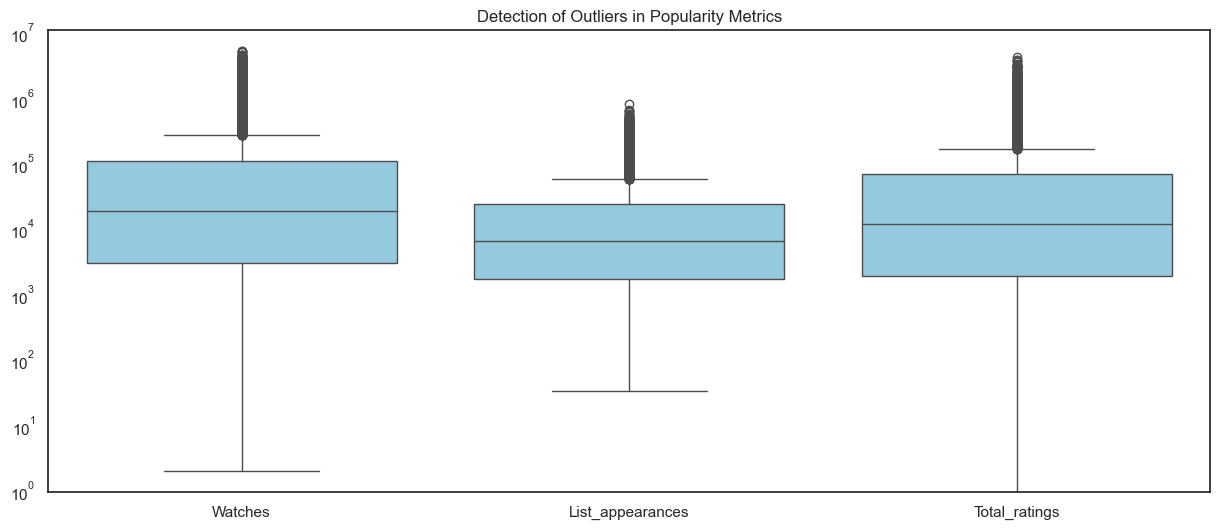

In [479]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=df[['Watches', 'List_appearances', 'Total_ratings']], color='skyblue') 
plt.yscale('log') # Set log scale for better visualization of outliers
plt.title('Detection of Outliers in Popularity Metrics')
plt.show()

### 3.6. Genres

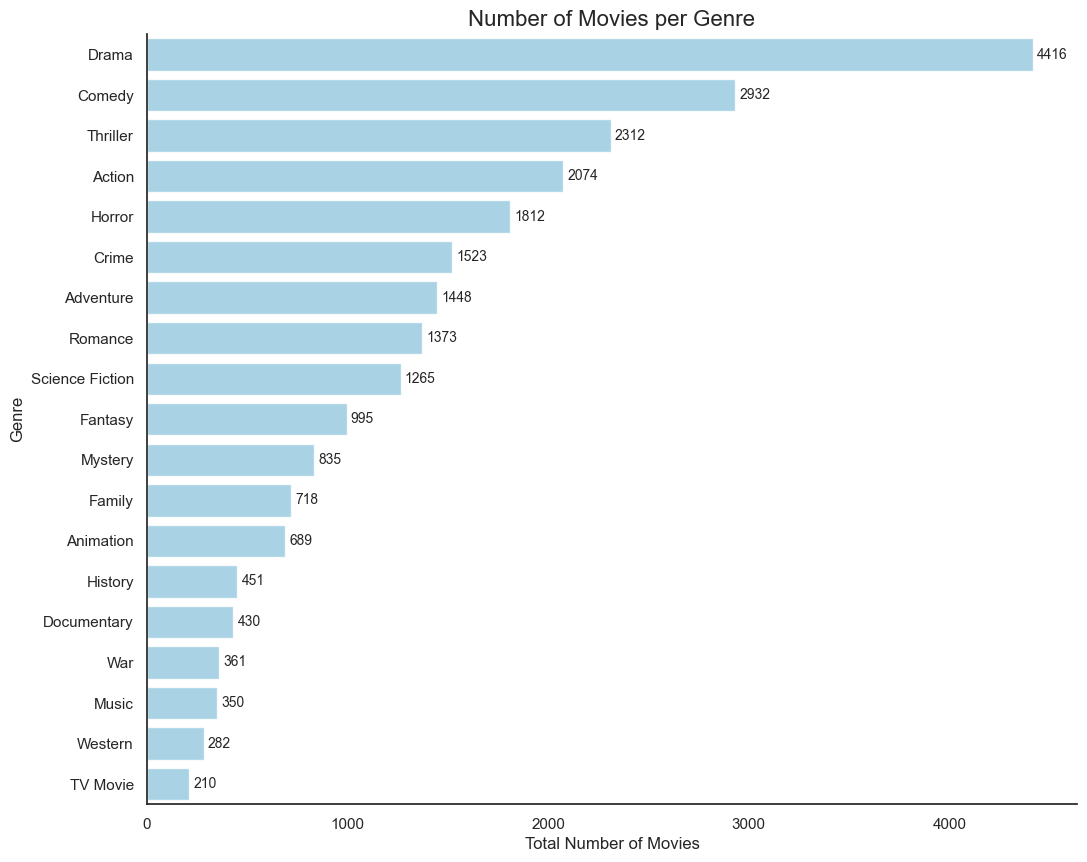

In [480]:
genre_counts = df[top_genres].sum().sort_values(ascending=False)

genre_df = genre_counts.reset_index()
genre_df.columns = ['Genre', 'Count']

plt.figure(figsize=(12, 10))

ax = sns.barplot(data=genre_df, x='Count', y='Genre', color='skyblue', alpha=0.8)

ax.bar_label(ax.containers[0], padding=3, fontsize=10)

plt.title('Number of Movies per Genre', fontsize=16)
plt.xlabel('Total Number of Movies', fontsize=12)
plt.ylabel('Genre', fontsize=12)

sns.despine()

plt.show()


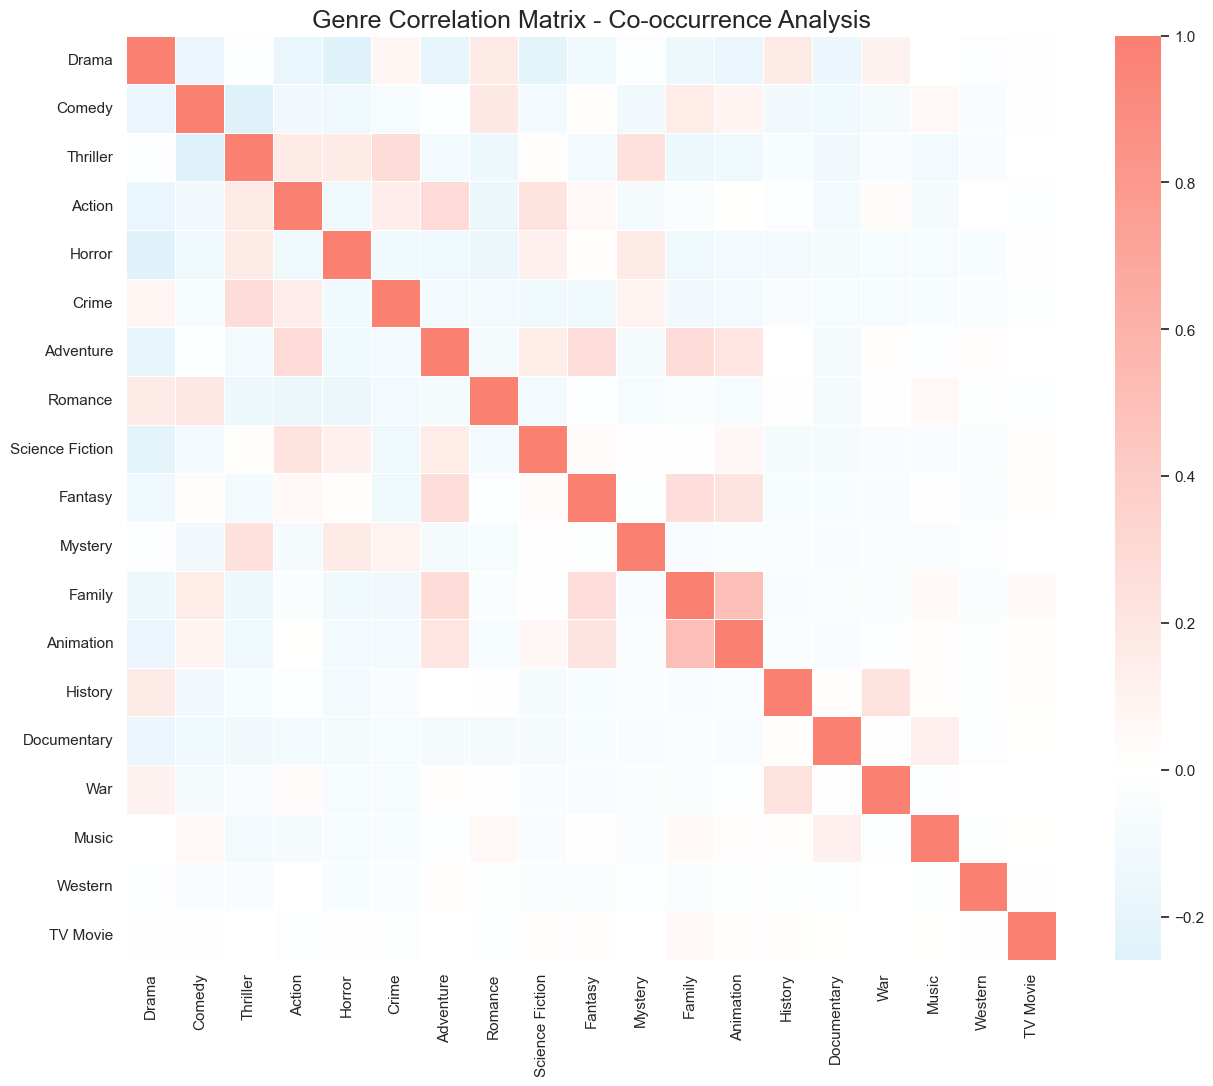

In [481]:
from matplotlib.colors import LinearSegmentedColormap

genre_data = df[top_genres]

genre_corr = genre_data.corr()

colors = ["skyblue", "white", "salmon"]
my_cmap = LinearSegmentedColormap.from_list("sky_salmon", colors)

plt.figure(figsize=(15, 12))


sns.heatmap(genre_corr, 
            annot=False, 
            cmap=my_cmap, 
            center=0, 
            linewidths=0.5, 
            linecolor='white')

plt.title('Genre Correlation Matrix - Co-occurrence Analysis', fontsize=18)
plt.show()

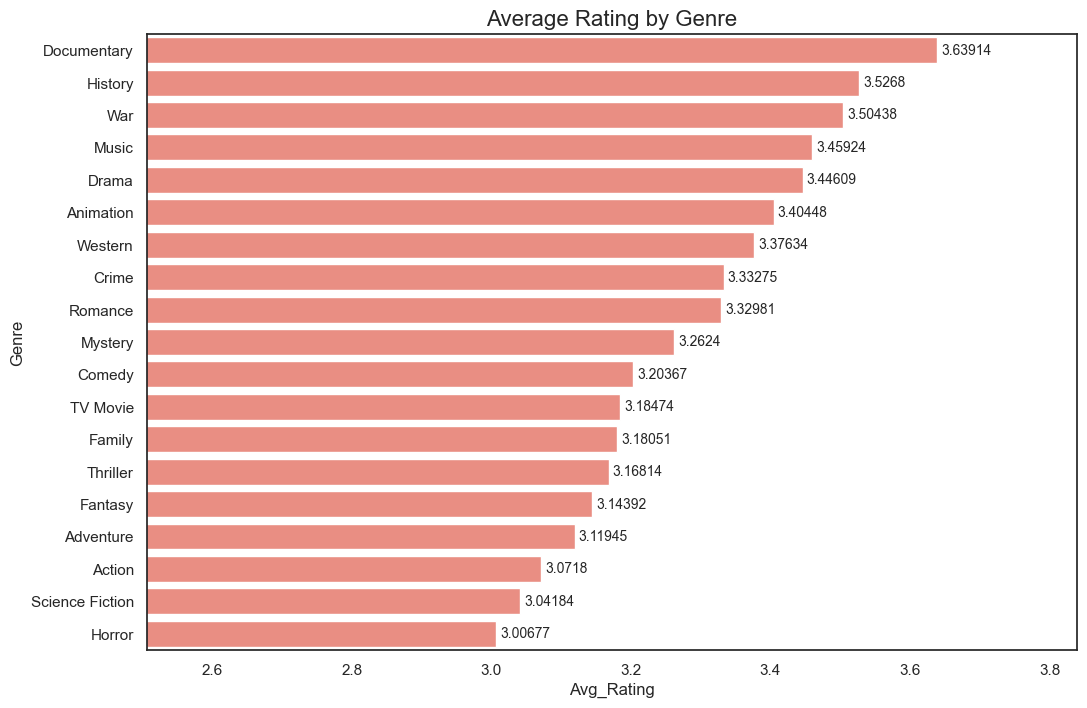

In [482]:
genre_means = {}
for g in top_genres:
    genre_means[g] = df[df[g] == 1]['Average_rating'].mean()

mean_df = pd.DataFrame(list(genre_means.items()), columns=['Genre', 'Avg_Rating']).sort_values('Avg_Rating', ascending=False)

plt.figure(figsize=(12, 8))
ax = sns.barplot(data=mean_df, x='Avg_Rating', y='Genre', color='salmon')
ax.bar_label(ax.containers[0], padding=3, fontsize=10)


plt.xlim(mean_df['Avg_Rating'].min() - 0.5, mean_df['Avg_Rating'].max() + 0.2)

plt.title('Average Rating by Genre', fontsize=16)
plt.show()

# 4. Classification column

We are creating new columns 'Rating_Class1' and 'Rating_Class2' based on the 'Average_rating' column.

In [483]:
def rating_class1(rating):

    '''
    Terrible: [0.0 to 2.5)
    Bad: [2.5 to 3.24)
    Average: [3.25 to 3.99)
    Best: [4.0 to 5.0)
    '''

    if rating < 2.5:
        return 'Terrible'
    elif rating < 3.25:
        return 'Bad'
    elif rating < 4:
        return 'Average'
    else:
        return 'Best'

df["Rating_Class1"] = df["Average_rating"].apply(rating_class1)
df['Rating_Class1'].value_counts()

Rating_Class1
Average     4895
Bad         3531
Terrible     798
Best         776
Name: count, dtype: int64

In [484]:
def rating_class2(rating):

    '''
    Bad/Mixed: [0.0 to 3.2)
    Good: [3.2 to 3.9)
    Masterpiece: [3.9 to 5.0)
    '''

    if rating < 3.2:
        return 'Bad/Mixed'
    elif rating < 3.9:
        return 'Good'
    else:
        return 'Masterpiece'

df["Rating_Class2"] = df["Average_rating"].apply(rating_class2)
df['Rating_Class2'].value_counts()

Rating_Class2
Good           4950
Bad/Mixed      3935
Masterpiece    1115
Name: count, dtype: int64

In [485]:
df.head(5)

,Average_rating,Runtime,Original_language,Watches,List_appearances,Total_ratings,Action,Adventure,Animation,Comedy,...,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western,Rating_Class1,Rating_Class2
0,3.57,92.0,German,12841,11032,9042,0,0,0,0,...,0,0,0,0,0,0,0,0,Average,Good
1,4.18,121.0,English,2488721,331681,1682389,1,1,0,0,...,0,0,0,1,0,0,0,0,Best,Masterpiece
2,3.93,99.0,English,618171,220094,443757,0,0,0,0,...,0,0,0,0,0,0,0,0,Average,Masterpiece
3,3.79,102.0,English,1596190,254180,1076949,0,0,0,1,...,0,0,1,0,0,0,0,0,Average,Good
4,4.28,124.0,Japanese,873068,175586,600721,1,0,1,0,...,0,0,0,1,0,0,0,0,Best,Masterpiece


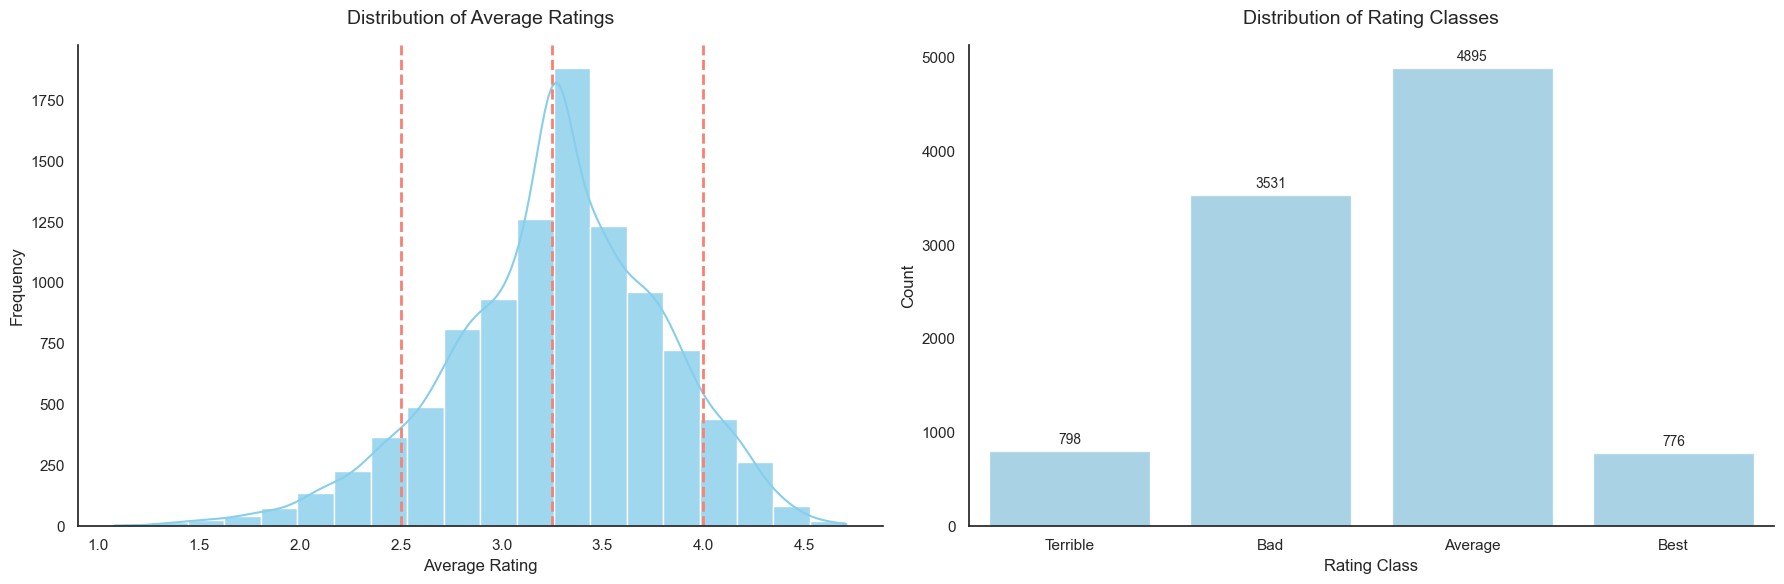

In [489]:
plot_data = df['Rating_Class1'].value_counts().reindex(['Terrible', 'Bad', 'Average', 'Best']).reset_index()
plot_data.columns = ['Rating Class', 'Count']

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18, 6))


sns.histplot(df['Average_rating'], bins=20, color='skyblue', edgecolor='white', alpha=0.8, ax=ax1, kde=True)

for pos in [2.5, 3.25, 4.0]:
    ax1.axvline(x=pos, color='salmon', linestyle='--', linewidth=2, label='Class Border' if pos == 2.5 else "")

ax1.set_title('Distribution of Average Ratings', fontsize=14, pad=15)
ax1.set_xlabel('Average Rating')
ax1.set_ylabel('Frequency')


sns.barplot(data=plot_data, x='Rating Class', y='Count', color='skyblue', alpha=0.8, ax=ax2)


ax2.bar_label(ax2.containers[0], padding=3, fontsize=10)

ax2.set_title('Distribution of Rating Classes', fontsize=14, pad=15)
ax2.set_xlabel('Rating Class')
ax2.set_ylabel('Count')

sns.despine()
plt.tight_layout()
plt.show()

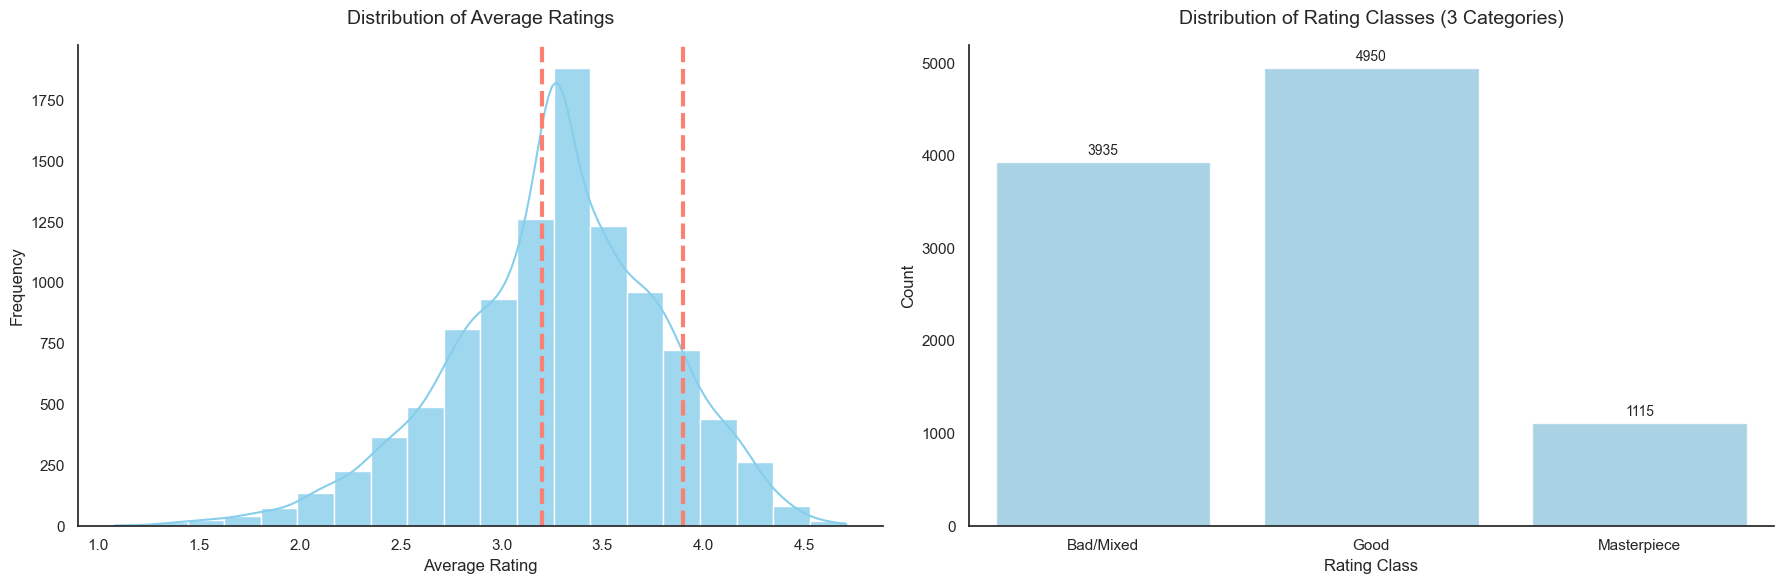

In [490]:
plot_data = df['Rating_Class2'].value_counts().reindex(['Bad/Mixed', 'Good', 'Masterpiece']).reset_index()
plot_data.columns = ['Rating Class', 'Count']

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18, 6))

sns.histplot(df['Average_rating'], bins=20, color='skyblue', edgecolor='white', alpha=0.8, ax=ax1, kde=True)

for pos in [3.2, 3.9]:
    ax1.axvline(x=pos, color='salmon', linestyle='--', linewidth=3, label='Threshold')

ax1.set_title('Distribution of Average Ratings', fontsize=14, pad=15)
ax1.set_xlabel('Average Rating')
ax1.set_ylabel('Frequency')

sns.barplot(data=plot_data, x='Rating Class', y='Count', color='skyblue', alpha=0.8, ax=ax2)

ax2.bar_label(ax2.containers[0], padding=3, fontsize=10)

ax2.set_title('Distribution of Rating Classes (3 Categories)', fontsize=14, pad=15)
ax2.set_xlabel('Rating Class')
ax2.set_ylabel('Count')

sns.despine() 
plt.tight_layout()
plt.show()

In [ ]:
df.drop(columns=['Average_rating'], inplace=True)

# 5. Random Forest (pierwszy)

In [453]:
df

,Runtime,Original_language,Watches,List_appearances,Total_ratings,Action,Adventure,Animation,Comedy,Crime,...,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western,Rating_Class1,Rating_Class2
0,92.0,German,12841,11032,9042,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Average,Good
1,121.0,English,2488721,331681,1682389,1,1,0,0,0,...,0,0,0,1,0,0,0,0,Best,Masterpiece
2,99.0,English,618171,220094,443757,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Average,Masterpiece
3,102.0,English,1596190,254180,1076949,0,0,0,1,0,...,0,0,1,0,0,0,0,0,Average,Good
4,124.0,Japanese,873068,175586,600721,1,0,1,0,0,...,0,0,0,1,0,0,0,0,Best,Masterpiece
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,205.0,English,108,163,56,0,0,0,0,0,...,0,0,0,0,1,1,0,0,Average,Good
9996,176.0,German,227,84,170,0,0,0,0,0,...,0,0,0,0,1,0,0,0,Average,Good
9997,89.0,German,82,43,61,0,0,0,0,0,...,0,0,0,0,1,0,0,0,Average,Good
9998,95.0,English,4239,1135,3274,0,0,0,0,0,...,0,0,0,1,0,1,0,0,Terrible,Bad/Mixed


# 6. (drugi)

In [454]:
df

,Runtime,Original_language,Watches,List_appearances,Total_ratings,Action,Adventure,Animation,Comedy,Crime,...,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western,Rating_Class1,Rating_Class2
0,92.0,German,12841,11032,9042,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Average,Good
1,121.0,English,2488721,331681,1682389,1,1,0,0,0,...,0,0,0,1,0,0,0,0,Best,Masterpiece
2,99.0,English,618171,220094,443757,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Average,Masterpiece
3,102.0,English,1596190,254180,1076949,0,0,0,1,0,...,0,0,1,0,0,0,0,0,Average,Good
4,124.0,Japanese,873068,175586,600721,1,0,1,0,0,...,0,0,0,1,0,0,0,0,Best,Masterpiece
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,205.0,English,108,163,56,0,0,0,0,0,...,0,0,0,0,1,1,0,0,Average,Good
9996,176.0,German,227,84,170,0,0,0,0,0,...,0,0,0,0,1,0,0,0,Average,Good
9997,89.0,German,82,43,61,0,0,0,0,0,...,0,0,0,0,1,0,0,0,Average,Good
9998,95.0,English,4239,1135,3274,0,0,0,0,0,...,0,0,0,1,0,1,0,0,Terrible,Bad/Mixed


# 7. (trzeci)

In [455]:
df

,Runtime,Original_language,Watches,List_appearances,Total_ratings,Action,Adventure,Animation,Comedy,Crime,...,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western,Rating_Class1,Rating_Class2
0,92.0,German,12841,11032,9042,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Average,Good
1,121.0,English,2488721,331681,1682389,1,1,0,0,0,...,0,0,0,1,0,0,0,0,Best,Masterpiece
2,99.0,English,618171,220094,443757,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Average,Masterpiece
3,102.0,English,1596190,254180,1076949,0,0,0,1,0,...,0,0,1,0,0,0,0,0,Average,Good
4,124.0,Japanese,873068,175586,600721,1,0,1,0,0,...,0,0,0,1,0,0,0,0,Best,Masterpiece
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,205.0,English,108,163,56,0,0,0,0,0,...,0,0,0,0,1,1,0,0,Average,Good
9996,176.0,German,227,84,170,0,0,0,0,0,...,0,0,0,0,1,0,0,0,Average,Good
9997,89.0,German,82,43,61,0,0,0,0,0,...,0,0,0,0,1,0,0,0,Average,Good
9998,95.0,English,4239,1135,3274,0,0,0,0,0,...,0,0,0,1,0,1,0,0,Terrible,Bad/Mixed
